In [25]:
# Imports
import copy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# SKlearn
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

# Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from pathlib import Path

# Dataset upload
df_path = Path.cwd().parent.parent / 'data' / 'processed' / 'final_dataset.csv'
df = pd.read_csv(df_path)

## Random Forest

In [26]:
metadata_cols = ['subject_id', 'video_id', 'window_id', 'frame_window_id', 'class'] #Medatata cols
feature_cols = [col for col in df.columns if col not in metadata_cols] #Feature cols to train Random Forest

agg_dict = {col: ['mean', 'std', 'min', 'max', 'median'] for col in feature_cols} #Agg features to group windows
agg_dict['class'] = 'first' #One class by window

# Features metrics calculation grouped by window_id
df_grouped = df.groupby(['subject_id', 'video_id', 'window_id']).agg(agg_dict)

# Var flatenned
df_grouped.columns = [f"{col}_{stat}" for col, stat in df_grouped.columns]

df_grouped = df_grouped.rename(columns={'class_first':'class'})

df_grouped = df_grouped.reset_index()

print(f"Dataset dimensions: {df_grouped.shape}")
print(df_grouped.head())

Dataset dimensions: (1756, 284)
  subject_id                  video_id                window_id  \
0   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_1   
1   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_10   
2   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_11   
3   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_12   
4   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_2   

   angle_left_shoulder_mean  angle_left_shoulder_std  angle_left_shoulder_min  \
0                 69.527475                 2.782518                65.118194   
1                 68.038256                 3.245179                63.023151   
2                 68.228825                 3.397394                62.470497   
3                 67.716621                 3.940782                59.372524   
4                 67.455335                 3.607940                58.703509   

   angle_left_shoulder_max  angle_left_shoulder_median  x_11_mean  x_11_std  \

In [27]:
#TEST: just points
angle_cols = [col for col in df.columns if col not in metadata_cols and not col.startswith("angle_")]
agg_dict = {col: ['mean', 'std', 'min', 'max', 'median'] for col in angle_cols} #Agg features to group windows
agg_dict['class'] = 'first' #One class by window

# Features metrics calculation grouped by window_id
df_grouped = df.groupby(['subject_id', 'video_id', 'window_id']).agg(agg_dict)

# Var flatenned
df_grouped.columns = [f"{col}_{stat}" for col, stat in df_grouped.columns]

df_grouped = df_grouped.rename(columns={'class_first':'class'})

df_grouped = df_grouped.reset_index()

print(f"Dataset dimensions: {df_grouped.shape}")
print(df_grouped.head())

Dataset dimensions: (1756, 244)
  subject_id                  video_id                window_id  x_11_mean  \
0   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_1   0.272477   
1   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_10   0.307162   
2   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_11   0.294311   
3   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_12   0.286807   
4   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_2   0.273848   

   x_11_std  x_11_min  x_11_max  x_11_median  y_11_mean  y_11_std  ...  \
0  0.029457  0.229183  0.335034     0.269455  -0.489437  0.097438  ...   
1  0.022800  0.281812  0.354818     0.298907  -0.479712  0.114027  ...   
2  0.014855  0.279526  0.331588     0.288706  -0.477179  0.110525  ...   
3  0.014740  0.263953  0.328612     0.284806  -0.502839  0.108273  ...   
4  0.031001  0.233036  0.335034     0.264526  -0.462646  0.113858  ...   

   z_28_std  z_28_min  z_28_max  z_28_median  v_28_mea

In [28]:
#TEST: just keypoints
angle_cols = [col for col in df.columns if col not in metadata_cols and col.startswith("angle_")]
agg_dict = {col: ['mean', 'std', 'min', 'max', 'median'] for col in angle_cols} #Agg features to group windows
agg_dict['class'] = 'first' #One class by window

# Features metrics calculation grouped by window_id
df_grouped = df.groupby(['subject_id', 'video_id', 'window_id']).agg(agg_dict)

# Var flatenned
df_grouped.columns = [f"{col}_{stat}" for col, stat in df_grouped.columns]

df_grouped = df_grouped.rename(columns={'class_first':'class'})

df_grouped = df_grouped.reset_index()

print(f"Dataset dimensions: {df_grouped.shape}")
print(df_grouped.head())

Dataset dimensions: (1756, 44)
  subject_id                  video_id                window_id  \
0   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_1   
1   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_10   
2   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_11   
3   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_12   
4   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_2   

   angle_left_shoulder_mean  angle_left_shoulder_std  angle_left_shoulder_min  \
0                 69.527475                 2.782518                65.118194   
1                 68.038256                 3.245179                63.023151   
2                 68.228825                 3.397394                62.470497   
3                 67.716621                 3.940782                59.372524   
4                 67.455335                 3.607940                58.703509   

   angle_left_shoulder_max  angle_left_shoulder_median  \
0                75.4

Unique subjects quantity: 106
---- INICIALIZATING VALIDATION BY SUBJECTS ----
Number of selected columns: 33
Accuracy: 0.93
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.94      0.99      0.96       138
           Other       0.91      0.94      0.93       171
         PushUps       0.98      0.80      0.88        71

        accuracy                           0.93       380
       macro avg       0.94      0.91      0.92       380
    weighted avg       0.93      0.93      0.93       380

--------------------------------------------------


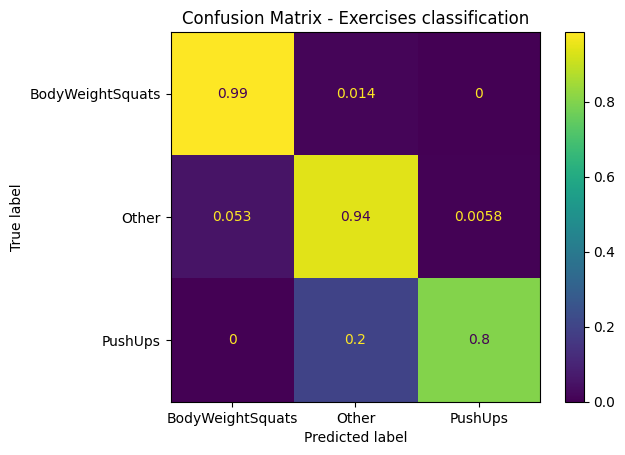

Number of selected columns: 31
Accuracy: 0.79
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.81      0.96      0.88       104
           Other       0.79      0.77      0.78       171
         PushUps       0.71      0.56      0.62        70

        accuracy                           0.79       345
       macro avg       0.77      0.76      0.76       345
    weighted avg       0.78      0.79      0.78       345

--------------------------------------------------


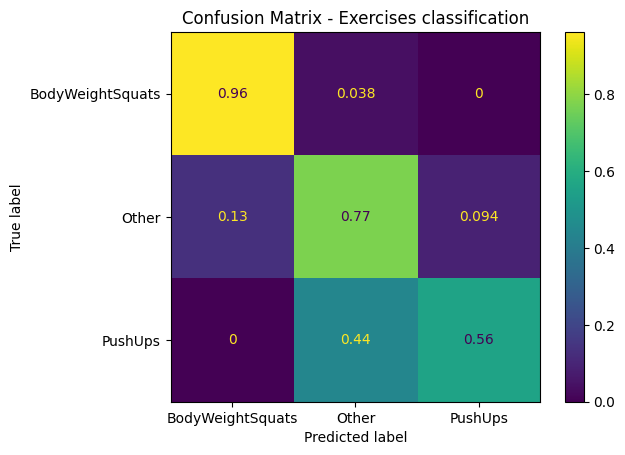

Number of selected columns: 33
Accuracy: 0.84
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.98      0.88      0.92       105
           Other       0.78      0.96      0.86       169
         PushUps       0.88      0.50      0.64        70

        accuracy                           0.84       344
       macro avg       0.88      0.78      0.81       344
    weighted avg       0.86      0.84      0.83       344

--------------------------------------------------


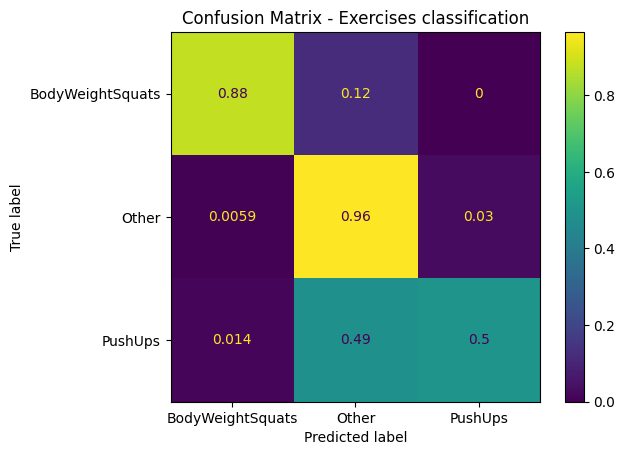

Number of selected columns: 32
Accuracy: 0.85
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.89      0.78      0.83       103
           Other       0.81      0.91      0.85       170
         PushUps       0.90      0.80      0.85        71

        accuracy                           0.85       344
       macro avg       0.87      0.83      0.84       344
    weighted avg       0.85      0.85      0.85       344

--------------------------------------------------


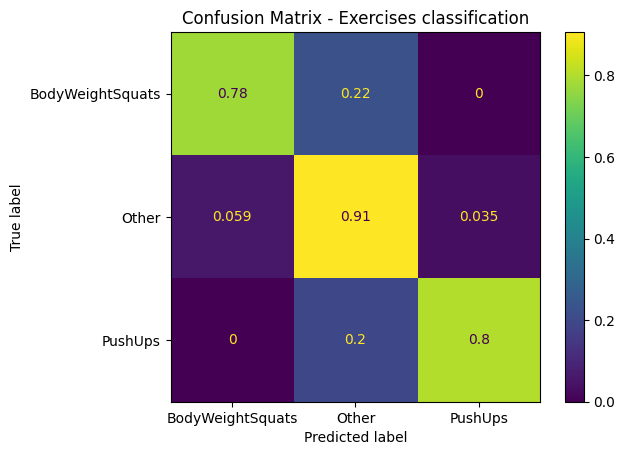

Number of selected columns: 32
Accuracy: 0.85
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.97      0.76      0.85       103
           Other       0.77      0.98      0.86       169
         PushUps       0.98      0.66      0.79        71

        accuracy                           0.85       343
       macro avg       0.91      0.80      0.84       343
    weighted avg       0.88      0.85      0.85       343

--------------------------------------------------


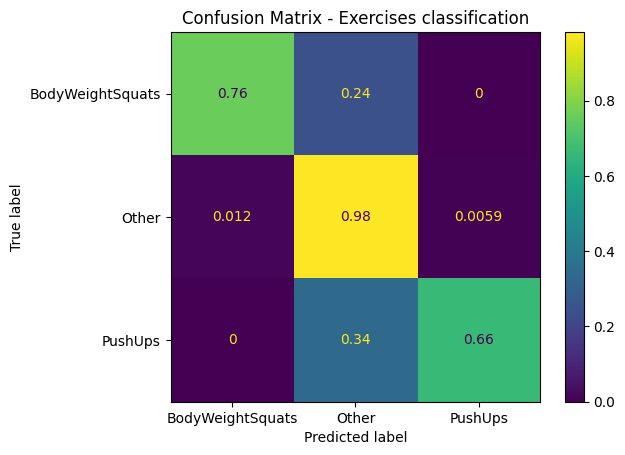

---- END VALIDATION ----


In [29]:
X = df_grouped.drop(columns=['subject_id', 'video_id', 'window_id', 'class'])
y = df_grouped['class']
groups = df_grouped['subject_id']
print(f"Unique subjects quantity: {len(groups.unique())}")

sgkf = StratifiedGroupKFold() #5 splits

all_y_test = []
all_y_pred = []

print("---- INICIALIZATING VALIDATION BY SUBJECTS ----")
for train_index, test_index in sgkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # ___Feature Selection___
    selector = SelectFromModel(
        RandomForestClassifier(
            n_estimators=50,
            random_state=1),
        threshold=0.01)
    selector.fit(X_train, y_train)
    
    # X_train y X_test filtering
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)
    #________________________

    # Model training
    model = RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                class_weight = "balanced"
            )
    model.fit(X_train_selected, y_train)

    # Model predictions
    y_pred = model.predict(X_test_selected)

    # Storage y_test and y_pred for outside loop
    all_y_test.append(y_test)
    all_y_pred.append(y_pred)

    print(f"Number of selected columns: {len(model.feature_importances_)}")

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    print("-" * 50)
        
    # Classificacion report
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        normalize='true'
    )
    plt.title("Confusion Matrix - Exercises classification")
    plt.show()

print("---- END VALIDATION ----")



## LSTM

In [30]:
class ActionRecognitionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, lstm_dropout = 0.0):
        super(ActionRecognitionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        #LSTM model configuration
        # batch_first=True then tensors [batch, seq_len, features]
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=lstm_dropout)
        
        # fully connected layer configuration
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x [batch, seq_len, features]
        
        # Hidden and cell state inicialization
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM training execution
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # Only takes the last parameter by bacth
        out = out[:, -1, :] 
        
        # fully connected layer
        out = self.fc(out)
        return out

In [31]:
# TEST Dimension reduction to angles
angle_cols = [col for col in df.columns if col not in metadata_cols and col.startswith("angle_")]
df_lstm_angle = df[metadata_cols + angle_cols].copy()
print(df_lstm_angle.shape)
# TEST Dimension reduction to keypoints
keypoint_cols = [col for col in df.columns if col not in metadata_cols and (col.startswith("x_") or col.startswith("y_") or col.startswith("z_"))]
df_lstm_kp = df[metadata_cols + keypoint_cols].copy()
print(df_lstm_kp.shape)

(105360, 13)
(105360, 41)


In [32]:
# Data splits
# Train group and TrainVal 70% and 30%
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=1)
train_idx, test_val_idx = next(gss_train.split(df_lstm_angle, groups=df_lstm_angle['subject_id']))

df_train = df_lstm_angle.iloc[train_idx].copy()
df_test_val = df_lstm_angle.iloc[test_val_idx].copy()

# Test and Val groups 15% and 15%
gss_test_val = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=1)
train_idx, val_idx = next(gss_test_val.split(df_test_val, groups=df_test_val['subject_id']))

df_test = df_test_val.iloc[train_idx].copy()
df_val = df_test_val.iloc[val_idx].copy()

print(f"Length inicial dataset: {len(df)}")
print(f"Length training dataset: {len(df_train)} - Percentaje {(len(df_train)/len(df))*100}%")
print(f"Length valuation dataset: {len(df_val)} - Percentaje {(len(df_val)/len(df))*100}%")
print(f"Length test dataset: {len(df_test)} - Percentaje {(len(df_test)/len(df))*100}%")

Length inicial dataset: 105360
Length training dataset: 74940 - Percentaje 71.12756264236903%
Length valuation dataset: 10620 - Percentaje 10.079726651480637%
Length test dataset: 19800 - Percentaje 18.79271070615034%


In [33]:
def tensor_transformation (df_tt):
    group_df = df_tt.groupby(['subject_id', 'video_id', 'window_id'], sort=False)
    
    sequences = []
    labels = []
    for name, group_data in group_df:
        sequences.append(group_data[angle_cols].values)
        labels.append(group_data['class'].iloc[0])

    # Classes to nums
    labels_num = [0 if l == "PushUps" else 1 if l == "BodyWeightSquats" else 2 for l in labels]

    # Tensor creation
    X_tensor = torch.tensor(np.array(sequences), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(labels_num), dtype=torch.long)

    return X_tensor, y_tensor

# LSTM data prep
scaler = StandardScaler()

# Fit and transform over df_train
df_train[angle_cols] = scaler.fit_transform(df_train[angle_cols])

# Just transform on df_val and df_test
df_val[angle_cols] = scaler.transform(df_val[angle_cols])
df_test[angle_cols] = scaler.transform(df_test[angle_cols])

X_train, y_train = tensor_transformation(df_train)
X_val, y_val = tensor_transformation(df_val)
X_test, y_test = tensor_transformation(df_test)

print("Train shapes")
print(f"    - X shape: {X_train.shape} -> (Batch, Sequence, Features)")
print(f"    - y shape: {y_train.shape} -> (Batch)")

print("Val shapes")
print(f"    - X shape: {X_val.shape} -> (Batch, Sequence, Features)")
print(f"    - y shape: {y_val.shape} -> (Batch)")

print("Test shapes")
print(f"    - X shape: {X_test.shape} -> (Batch, Sequence, Features)")
print(f"    - y shape: {y_test.shape} -> (Batch)")

Train shapes
    - X shape: torch.Size([1249, 60, 8]) -> (Batch, Sequence, Features)
    - y shape: torch.Size([1249]) -> (Batch)
Val shapes
    - X shape: torch.Size([177, 60, 8]) -> (Batch, Sequence, Features)
    - y shape: torch.Size([177]) -> (Batch)
Test shapes
    - X shape: torch.Size([330, 60, 8]) -> (Batch, Sequence, Features)
    - y shape: torch.Size([330]) -> (Batch)


In [34]:
# Path to store LSTM model weigth
lstm_path = Path.cwd().parent.parent / 'models' / 'lstm_classifier'
lstm_path.mkdir(parents=True, exist_ok=True)

# Packing X_train and y_train
train_tdataset = TensorDataset(X_train, y_train)
# Group by 30 batches groups and shuffle data
train_loader = DataLoader(train_tdataset, batch_size=30, shuffle=True)

# Packing X_val and y_val
val_tdataset = TensorDataset(X_val, y_val)
# Group by 30 batches groups and shuffle data
val_loader = DataLoader(val_tdataset, batch_size=30, shuffle=True)

# Model declaration
model = ActionRecognitionLSTM(
    input_size=len(angle_cols),
    hidden_size=16, 
    num_layers=1, 
    num_classes=len(y_train.unique()),
    lstm_dropout=0
    )

# Loss function
celoss = nn.CrossEntropyLoss() 

# Optimizer Adam for adjust the training velocity
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Model to GPU if it is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

num_epochs = 100

best_accuracy = -1
epoch_counter = 0
best_model_weights = None

# ___ Training loop ___
for epoch in range(num_epochs):
    #====TRAINING PHASE====
    model.train()
    train_loss = 0
    # 30 by 30 to don't saturate memory
    for X_batch, y_batch in train_loader:
        # Send batches to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Gradient cleaning
        optimizer.zero_grad()
        
        # Forward pass
        y_train_p = model(X_batch)
        
        # Loss calculation
        loss = celoss(y_train_p, y_batch)
        
        # Backward pass
        loss.backward()
        
        # Weight update
        optimizer.step()

        train_loss += loss.item()
    
    mean_loss_train = train_loss / len(train_loader)

    #====VALIDATION PHASE====
    model.eval()
    val_loss = 0
    correct_predictions = 0
    total = 0

    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            # Send batches to device
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)

            # Forward pass
            y_val_p = model(X_val_batch)

            # Loss calculation
            loss_v = celoss(y_val_p, y_val_batch)

            val_loss += loss_v.item()

            predictions = torch.argmax(y_val_p, dim=1)
            correct_predictions += (predictions == y_val_batch).sum().item()
            total += y_val_batch.size(0)

    mean_loss_val = val_loss / len(val_loader)
    accuracy = (correct_predictions / total) * 100

    # Best model saving
    if best_accuracy < accuracy:
        best_accuracy = accuracy
        epoch_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        epoch_counter += 1

    # Early stopping
    if epoch_counter == 10:
        torch.save(best_model_weights, lstm_path / 'best_model.pth')
        print(f"Model saved on epoch {epoch}. Best accuracy {best_accuracy}")
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"    - Train error: {mean_loss_train}")
        print(f"    - Val error: {mean_loss_val} | Val accuracy: {accuracy}%")
        print(f"    - Best val accuracy: {best_accuracy}%")

Epoch [10/100]
    - Train error: 0.3843943150270553
    - Val error: 0.3938923378785451 | Val accuracy: 87.57062146892656%
    - Best val accuracy: 88.13559322033898%
Epoch [20/100]
    - Train error: 0.2416557575620356
    - Val error: 0.34358132630586624 | Val accuracy: 88.70056497175142%
    - Best val accuracy: 90.3954802259887%
Model saved on epoch 23. Best accuracy 90.3954802259887


Accuracy: 0.84
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

         PushUps       0.70      1.00      0.82        33
BodyWeightSquats       0.68      0.85      0.75        71
           Other       0.94      0.81      0.87       226

        accuracy                           0.84       330
       macro avg       0.78      0.89      0.82       330
    weighted avg       0.86      0.84      0.84       330

--------------------------------------------------


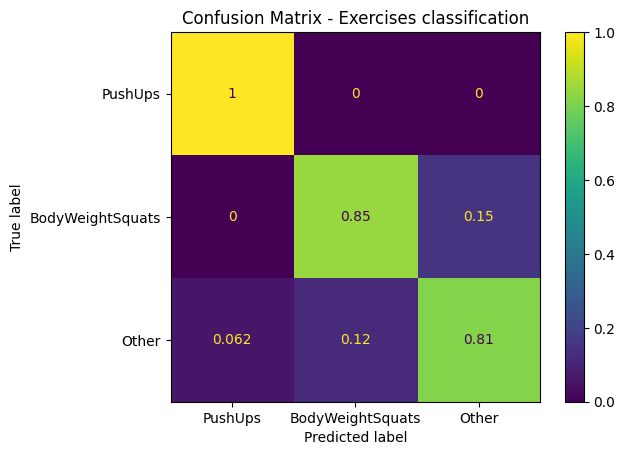

In [35]:
# Packing X_val and y_val
test_tdataset = TensorDataset(X_test, y_test)
# Group by 30 batches groups and shuffle data
test_loader = DataLoader(test_tdataset, batch_size=30, shuffle=False)

best_model = ActionRecognitionLSTM(
    input_size=len(angle_cols),
    hidden_size=16, 
    num_layers=1, 
    num_classes=len(y_train.unique()),
    lstm_dropout=0
    )

best_model.load_state_dict(torch.load(lstm_path / 'best_model.pth' , weights_only = True))
best_model = best_model.to(device)
best_model.eval()

# lists to storage results
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for X_test_batch, y_test_batch in test_loader:
        # Send to GPU/CPU
        X_test_batch = X_test_batch.to(device)
        y_test_batch = y_test_batch.to(device)
        
        # Forward pass
        y_test_pred = best_model(X_test_batch)
        
        # More prob class
        predictions = torch.argmax(y_test_pred, dim=1)
        
        # Move to list
        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(y_test_batch.cpu().numpy())

# Convertir a arrays de numpy para sklearn
y_true = np.array(all_true_labels)
y_pred = np.array(all_predictions)

target_names = ['PushUps' if i == 0 else "BodyWeightSquats" if i == 1 else "Other" for i in range(len(np.unique(y_true)))]

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("-" * 50)

# Classificacion report
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=target_names))
print("-" * 50)

ConfusionMatrixDisplay.from_predictions(
    y_true, 
    y_pred, 
    display_labels=target_names,
    normalize='true'
)
plt.title("Confusion Matrix - Exercises classification")
plt.show()

## Model selected training

In [36]:
from sklearn.pipeline import Pipeline
import joblib

# Path to store LSTM model weigth
rf_path = Path.cwd().parent.parent / 'models' / 'rf_classifier'
rf_path.mkdir(parents=True, exist_ok=True)
                
print("---- RANDOM FOREST TRAINING WITH ALL DATA ----")

# Pipeline definition
pipeline= Pipeline([
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=50, random_state=1), 
        threshold=0.01)
    ),
    ('clasificator', RandomForestClassifier(
        n_estimators=150, 
        max_depth=12, 
        class_weight="balanced", 
        random_state=1)
    )
])

# 2. All data training
pipeline.fit(X, y)

# Selector form pipeline
selector_final = pipeline.named_steps['feature_selection']

# Col names
best_vars = X.columns[selector_final.get_support()]

print(f"\nBest vars num: {len(best_vars)}")
print("Most importances var")
print(list(best_vars))

# 4. Saving model
joblib.dump(pipeline, rf_path / "side_rf_model.joblib")
print("\nModel saved")

---- RANDOM FOREST TRAINING WITH ALL DATA ----

Best vars num: 34
Most importances var
['angle_left_shoulder_mean', 'angle_left_shoulder_min', 'angle_left_shoulder_max', 'angle_left_shoulder_median', 'angle_right_shoulder_mean', 'angle_right_shoulder_std', 'angle_right_shoulder_min', 'angle_right_shoulder_max', 'angle_right_shoulder_median', 'angle_left_elbow_std', 'angle_left_elbow_min', 'angle_right_elbow_std', 'angle_right_elbow_min', 'angle_right_elbow_median', 'angle_left_hip_mean', 'angle_left_hip_std', 'angle_left_hip_min', 'angle_left_hip_max', 'angle_left_hip_median', 'angle_right_hip_mean', 'angle_right_hip_std', 'angle_right_hip_min', 'angle_right_hip_max', 'angle_right_hip_median', 'angle_left_knee_mean', 'angle_left_knee_std', 'angle_left_knee_min', 'angle_left_knee_max', 'angle_left_knee_median', 'angle_right_knee_mean', 'angle_right_knee_std', 'angle_right_knee_min', 'angle_right_knee_max', 'angle_right_knee_median']

Model saved
